In [7]:
# %%
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.signal import butter, sosfiltfilt
from scipy.signal.windows import tukey

In [8]:
data_dir = "../fin_whale"
files = sorted([f for f in os.listdir(data_dir) if f.endswith(".h5")])
print(f"Found {len(files)} files in directory.")
if len(files) > 0:
    print("Example files:", files[:5])

Found 113 files in directory.
Example files: ['signal_10017.h5', 'signal_10076.h5', 'signal_10078.h5', 'signal_10079.h5', 'signal_10080.h5']


In [9]:
# ====== Select one file to inspect ======

file_name = "signal_66582.h5"


'''
clear ---
"signal_66582.h5"
"signal_7402.h5"
"signal_9660.h5"
"signal_11183.h5"
"signal_20099.h5"
"signal_20151.h5"

partial --
"signal_38865.h5"
"signal_2138.h5"
"signal_9704.h5"
"signal_9414.h5"
"signal_9441.h5"
"signal_20175.h5"

faint --
"signal_1834.h5"
"signal_1822.h5"
"signal_2097.h5"
"signal_17195.h5"
"signal_5527.h5"
"signal_16446.h5"

'''

file_path = os.path.join(data_dir, file_name)
print(f"\nReading file: {file_path}")

# %%
# ====== Read HDF5 content ======
with h5py.File(file_path, "r") as f:
    data = f["data"][:]  # shape: [channels, time_samples]
    attrs = dict(f["data"].attrs)

print(f"Data shape: {data.shape} (channels × time samples)")
print("Attributes:")
for k, v in attrs.items():
    print(f"  {k}: {v}")

# %%
# ====== Build time axis ======
dt = float(attrs.get("dt_s", 0.005))
t = np.arange(data.shape[1]) * dt
print(f"Sampling interval dt = {dt:.6f} s, total duration = {t[-1]:.2f} s")

# %%
# ====== Basic statistics ======
mean_val = np.mean(data)
std_val = np.std(data)
print(f"Mean: {mean_val:.4f}, Std: {std_val:.4f}")
print(f"Max: {np.max(data):.4f}, Min: {np.min(data):.4f}")


Reading file: ../fin_whale/signal_66582.h5
Data shape: (2843, 1385) (channels × time samples)
Attributes:
  dt_s: 0.005
  end_idx: 2100
  event_id: 66582
  snr_top40_mean: 1.027149214659686
  start_idx: 715
  y_max: 10244
  y_min: 7401
Sampling interval dt = 0.005000 s, total duration = 6.92 s
Mean: -308892.2500, Std: 78257472.0000
Max: 1981676160.0000, Min: -1993912320.0000


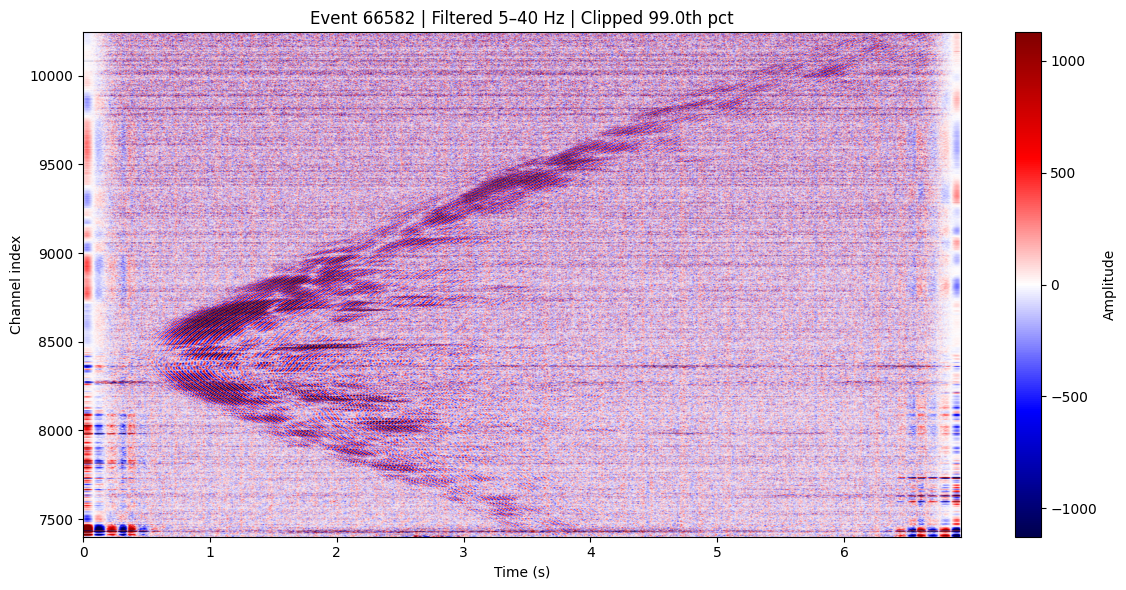

In [4]:
# ====== Filter and clip the data, then plot again ======

def bandpass(data, fs, lowcut=5, highcut=4, order=4):
    # Taper edges to reduce edge transients
    window = tukey(data.shape[1], alpha=0.1)
    data_tapered = data * window[np.newaxis, :]
    
    sos = butter(order, [lowcut, highcut], btype="band", fs=fs, output="sos")
    return sosfiltfilt(sos, data_tapered, axis=1)

fs = 1.0 / float(attrs.get("dt_s", 0.005))  # e.g. 200 Hz if dt=0.005
band = [5, 40]

data_detrend = data - np.median(data, axis=1, keepdims=True)
data_filt = bandpass(data_detrend, fs, lowcut=band[0], highcut=band[1])

clip_percent = 99.0
vmax = np.percentile(np.abs(data_filt), clip_percent)

plt.figure(figsize=(12, 6))
plt.imshow(
    data_filt,
    aspect="auto",
    cmap="seismic",
    origin="lower",
    vmin=-vmax,
    vmax=vmax,
    extent=[t[0], t[-1], attrs.get("y_min", 0), attrs.get("y_max", data.shape[0])],
)

plt.title(f"Event {attrs.get('event_id', '?')} | Filtered {band[0]}–{band[1]} Hz | Clipped {clip_percent}th pct")
plt.xlabel("Time (s)")
plt.ylabel("Channel index")
plt.colorbar(label="Amplitude")
plt.tight_layout()
plt.show()